# Поліноміальна регресія та регуляризація

Не завжди пряма лінія гарно апроксимує експериментальні результати, краще підходять варіанти
сублінійні (з швидкістю зростання повільніші ніж пряма лінія) або гіперлінійні.

У той же час, чисті поліноми ($\sum_{i=0}^{n}a_i\cdot x^i$) не годяться для задач передбачення, 
оскільки мають "хвости" (у далеких областях від даних), що дуже швидко змінюються.

## Завдання 1
Перевірте, як поліноміальні ознаки впливають на якість моделі:
- Згенеруйте синтетичні дані за допомогою make_regression (n_samples=200, n_features=1, noise=15, random_state=42).
- Побудуйте модель лінійної регресії на вихідних даних.
- Додайте поліноміальні ознаки ступеня 2 за допомогою PolynomialFeatures.
- Навчіть модель на розширеному наборі ознак.
- Побудуйте графік: вихідні точки та лінії передбачень для обох моделей.

In [1]:
# Згенеруйте синтетичні дані за допомогою make_regression (n_samples=200, n_features=1, noise=15, random_state=42).
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=200, n_features=1, noise=150, random_state=42)
print(X[:5], y[:5])

[[ 1.85227818]
 [ 0.47359243]
 [-1.23086432]
 [ 0.62566735]
 [-0.07201012]] [-28.11687095 172.43296329 127.51212144  99.21599695 -25.57979614]


In [2]:
# Побудуйте модель лінійної регресії на вихідних даних.
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()
model1.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [3]:
# Додайте поліноміальні ознаки ступеня 2 за допомогою PolynomialFeatures.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
model2 = make_pipeline(              # pipeline - послідовність кількох
    PolynomialFeatures(degree=2),    # базових елементів моделей,
    LinearRegression()               # зокрема попередньої обробки 
)                                    # (preprocessing)
# Навчіть модель на розширеному наборі ознак.
model2.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


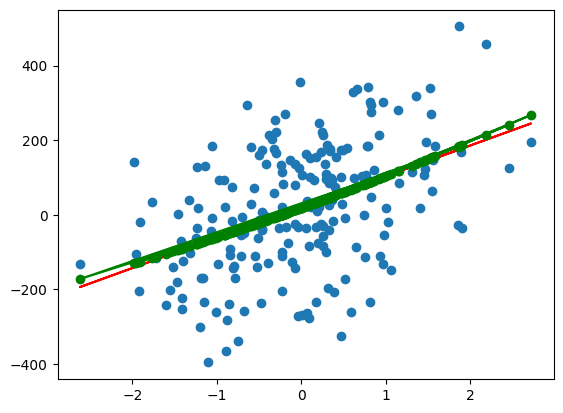

In [4]:
# Побудуйте графік: вихідні точки та лінії передбачень для обох моделей.
import matplotlib.pyplot as plt
_,ax = plt.subplots()
ax.scatter(X,y)
ax.plot(X, model1.predict(X), 'r-')
ax.plot(X, model2.predict(X), 'g-o')
plt.show()

## Завдання 2
Порівняйте моделі з різним ступенем полінома і проаналізуйте перенавчання:
- Використовуйте синтетичні дані (make_regression, n_samples=200, n_features=1, noise=20).
- Побудуйте моделі для ступенів полінома: 2, 5, 10.
- Розділіть дані на навчальну і тестову вибірки (80/20, random_state=42).
- Для кожної моделі обчисліть R² на навчальній і тестовій вибірках.
- Оформіть результати в таблиці:

|Ступінь полінома|Навч. R²|Тест. R²|
|-|-|-|
|2|...|...|
|5|...|...|
|10|...|...|

In [5]:
# Використовуйте синтетичні дані (make_regression, n_samples=200, n_features=1, noise=20).
X2, y2 = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)

# Побудуйте моделі для ступенів полінома: 2, 5, 10
degrees = [2, 5, 10]
models = [make_pipeline( PolynomialFeatures(degree=degree), LinearRegression() ) for degree in degrees]

# Розділіть дані на навчальну і тестову вибірки (80/20, random_state=42).
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X2, y2, test_size=0.2, random_state=42)
for model in models: 
    model.fit(xtrain, ytrain)
    
# Для кожної моделі обчисліть R² на навчальній і тестовій вибірках.
# Оформіть результати в таблиці:
from IPython.display import Markdown as md
import sklearn.metrics as sm

md("|Ступінь полінома|Навч. R²|Тест. R²|\n|-|-|-|\n" + 
   "\n".join(
       f"|{degrees[i]}|{1 - abs(sm.r2_score(ytrain, models[i].predict(xtrain)))}|{1 - abs(sm.r2_score(ytest, models[i].predict(xtest)))}|" 
       for i in range(len(degrees))
    )
)

|Ступінь полінома|Навч. R²|Тест. R²|
|-|-|-|
|2|0.060024063204569655|0.05504586763666841|
|5|0.05840879647459152|0.11386687620529401|
|10|0.05710277569672384|-30.840955119114362|

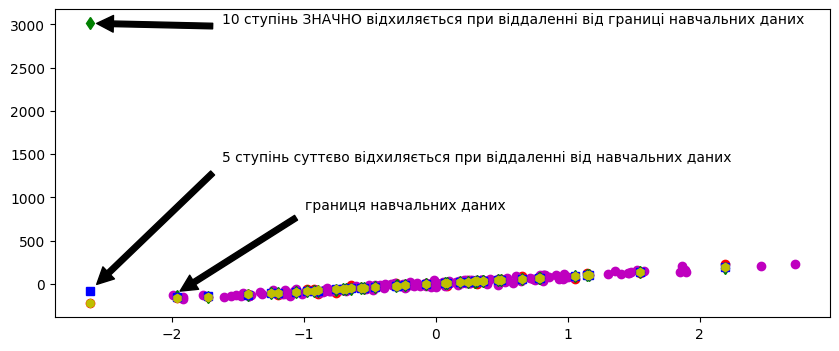

In [6]:
pred2 = models[0].predict(xtest)
pred5 = models[1].predict(xtest)
pred10 = models[2].predict(xtest)
_,ax = plt.subplots(figsize=(10,4))
ax.plot(xtest, ytest, 'ro')
ax.plot(xtrain, ytrain, 'mo')
ax.plot(xtest, pred10, 'gd')
ax.plot(xtest, pred5, 'bs')
ax.plot(xtest, pred2, 'yh')
# for p in range(len(ytest)):
p = 15
ax.annotate("10 ступінь ЗНАЧНО відхиляється при віддаленні від границі навчальних даних",
            (xtest[p][0], pred10[p]),(xtest[p][0] + 1, pred10[p]),
            arrowprops=dict(facecolor='black', shrink=0.05),)
ax.annotate("5 ступінь суттєво відхиляється при віддаленні від навчальних даних",
            (xtest[p][0], pred5[p]),(xtest[p][0] + 1, pred5[p] + 1500),
            arrowprops=dict(facecolor='black', shrink=0.05),)
# for p in range(50,70):
p = 65
ax.annotate("границя навчальних даних", 
            (xtrain[p][0], ytrain[p]),(xtrain[p][0] + 1, ytrain[p] + 1000),
            arrowprops=dict(facecolor='black', shrink=0.05),)
plt.show()

## Завдання 3
Застосуйте Lasso і порівняйте результат зі звичайною лінійною регресією:
- Згенеруйте дані за допомогою make_regression (n_samples=500, n_features=20, n_informative=5, noise=10, random_state=42).
- Навчіть модель LinearRegression і модель Lasso(alpha=0.1).
- Розділіть дані на train/test(80/20, random_state=42).
- Порівняйте R² на тестовій вибірці.
- Виведіть кількість коефіцієнтів, які Lasso занулила.

LASSO - Least Absolute Shrinkage and Selection Operator - Модифікація регресійного аналізу за якої
вводиться найменша величина коефіцієнтів, менше за яку (за модулем) вони автоматично "обрізаються" до нуля.
Це еквівалентно поділу змінних на значущі та незначущі з вибором лише перших.

alpha=0.1 - множник у методі визначення відхилення точок від прогнозованої лінії. 
При alpha=0 це звичайний МНК (метод найменших квадратів). При цьому LASSO перетворюється на лінійну регресію
Від'ємні значення не допускаються, за замовчанням alpha=1

In [68]:
X3, y3 = make_regression(n_samples=500, n_features=20, n_informative=5, noise=10, random_state=42)
x3train, x3test, y3train, y3test = train_test_split(X3, y3, test_size=0.2, random_state=42)
# X3[0]
from sklearn.linear_model import LinearRegression, Lasso
lr_model = LinearRegression()
lasso_model = Lasso(alpha=0.1)
lr_model.fit(x3train, y3train)
lasso_model.fit(x3train, y3train)
print(*(f"{c1:.3f}\t{c2:.3f}"  for c1, c2 in zip(lr_model.coef_, lasso_model.coef_)), sep='\n')

-0.048	-0.000
0.454	0.342
7.340	7.220
-0.557	-0.454
-0.438	-0.362
0.369	0.280
58.730	58.636
31.338	31.239
0.218	0.106
10.601	10.540
-0.785	-0.685
0.018	0.000
0.811	0.718
9.397	9.291
-0.071	-0.000
-0.007	-0.000
0.097	0.000
0.023	-0.000
0.688	0.573
-0.090	-0.010


In [69]:
# Порівняйте R² на тестовій вибірці.
print(f"Коефіцієнти детермінації (R²): лінійна регресія {1}, LASSO-модель {1}")
# Виведіть кількість коефіцієнтів, які Lasso занулила
print(f"кількість коефіцієнтів, які Lasso занулила: {1}")

Коефіцієнти детермінації (R²): лінійна регресія 1, LASSO-модель 1
кількість коефіцієнтів, які Lasso занулила: 1


## Завдання 4
Перевірте вплив Ridge-регуляризації на якість моделі:
- Використовуйте ті самі дані, що й у Завданні 3.
- Навчіть модель LinearRegression і модель Ridge(alpha=1.0).
- Розділіть дані на train/test (80/20, random_state=42).
- Порівняйте R² на тестовій вибірці.
- Виведіть таблицю порівняння:

|Модель|Тест R²|Кількість ненульових коеф.|
|-|-|-|
|LinearRegression|...|...|
|Lasso(alpha=0.1)|...|...
|Ridge(alpha=1.0)|...|...

In [70]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x3train, y3train)
print(f"Коефіцієнт детермінації (R²) для моделі Ridge: {1}")

Коефіцієнт детермінації (R²) для моделі Ridge: 1


In [71]:
import numpy as np

md("\n".join((
    "|Модель|Тест R²|Кількість ненульових коеф.|",
    "|-|-|-|",
    "|LinearRegression|%f|%d|",
    "|Lasso(alpha=0.1)|%f|%d|",
    "|Ridge(alpha=1.0)|%f|%d|",
)) % (
    sm.r2_score(y3test, lr_model.predict(x3test)), np.sum(lr_model.coef_ != 0),
    sm.r2_score(y3test, lasso_model.predict(x3test)), np.sum(lasso_model.coef_ != 0),
    sm.r2_score(y3test, ridge_model.predict(x3test)), np.sum(ridge_model.coef_ != 0),
))

|Модель|Тест R²|Кількість ненульових коеф.|
|-|-|-|
|LinearRegression|0.978411|20|
|Lasso(alpha=0.1)|0.978785|14|
|Ridge(alpha=1.0)|0.978487|20|